# Extra example: classifying clothing photos with Fashion-MNIST

**Dataset: Fashion-MNIST.** A real, public dataset released by Zalando Research
(the online clothing retailer), built specifically as a drop-in replacement for the
classic digit-MNIST dataset used in the book's own Section 4.4.1. Source:
https://github.com/zalandoresearch/fashion-mnist. It has the exact same shape as
digit-MNIST - 70,000 grayscale images, 28x28 pixels each - but instead of digits
0-9, each image shows one of 10 clothing items:

| Label | Item |
|---|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

Because it has the same format as digit-MNIST, every technique from Chapter 4 - and
from the Chapter 4 homework's Exercise 15 - transfers directly: the same train/
validation/test split logic, the same `StandardScaler` fit-on-training-data-only
rule (Reasoning Question 9), the same model comparison approach, and the same idea
of predicting from your own photo.

**A daily-life angle:** the same pipeline built here is a small building block for
things like a closet-inventory app or auto-tagging photos when listing an item for
resale online - snap a photo of a piece of clothing, and have it automatically
sorted into a category.

The data was downloaded directly from the official GitHub repository above (the
original `idx-ubyte` files) and the first 10,000 training rows were kept as a CSV,
in the same format used for the digit-MNIST notebook (first column = label,
remaining 784 columns = pixel values 0-255).


### Step 1: Load the data and take a first look

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

fashion_df = pd.read_csv("fashion_mnist_10k.csv", header=None)
y = fashion_df.iloc[:, 0].to_numpy().astype(np.uint8)
X = fashion_df.iloc[:, 1:].to_numpy().astype(np.float64)

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("X shape:", X.shape, " y shape:", y.shape)
print("Number of images per class:", np.bincount(y))


X shape: (10000, 784)  y shape: (10000,)
Number of images per class: [ 942 1027 1016 1019  974  989 1021 1022  990 1000]


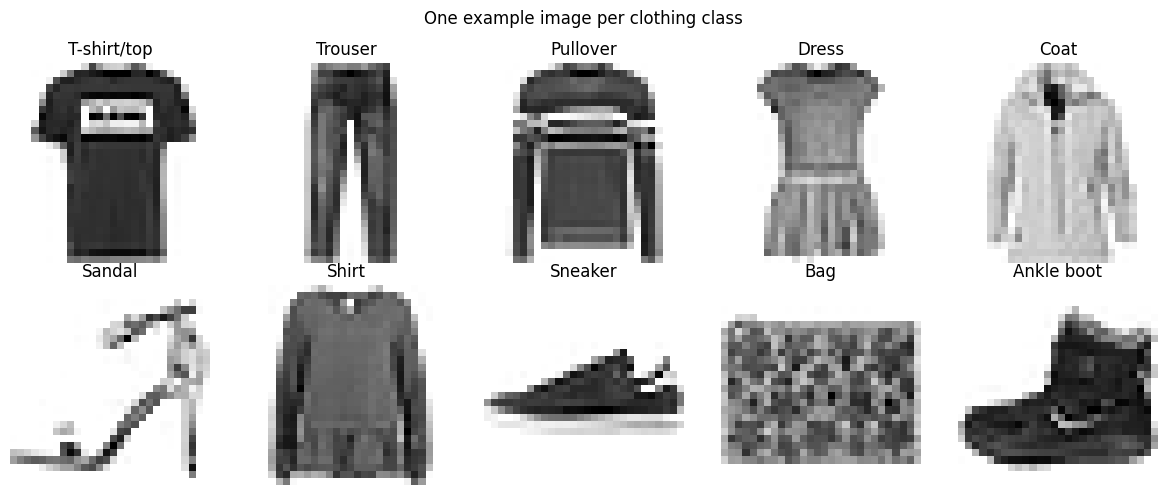

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit_class in range(10):
    idx = np.where(y == digit_class)[0][0]
    ax = axes[digit_class // 5, digit_class % 5]
    ax.imshow(X[idx].reshape(28, 28), cmap=mpl.cm.binary)
    ax.set_title(class_names[digit_class])
    ax.axis("off")
plt.suptitle("One example image per clothing class")
plt.tight_layout()
plt.show()


### Step 2: Train / validation / test split, then scale

Same approach as Chapter 4's Exercise 15: split the data first, then fit
`StandardScaler` only on the training data and only `.transform()` the validation
and test data (Reasoning Question 9's rule, to avoid data leakage).


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=1500, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=1500, random_state=42, stratify=y_train_val
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform on training data only
X_val_scaled = scaler.transform(X_val)           # transform only on validation data

print("Training images:", X_train_scaled.shape[0])
print("Validation images:", X_val_scaled.shape[0])
print("Test images:", X_test.shape[0])


Training images: 7000
Validation images: 1500
Test images: 1500


### Step 3: Compare four models on the validation set

This reproduces the book's own Section 4.4.1 methodology in full - Logistic
Regression, Random Forest, Extra Trees, and a soft-voting ensemble of the three -
which is exactly the comparison that was missing from the Chapter 4 homework
delivery's Exercise 15.
